# EfficientNet-B0 / EfficientNet-B2 – Multi-Label Apparel Classification

## Task 3.1 – Multi-Label Classification

This notebook implements:

- EfficientNet-B0 or B2 (Fine-Tuning)
- EfficientNet-B0 or B2 (Training from Scratch)
- EfficientNet-B0 or B2 (Transfer Learning — frozen backbone)

**Switch between B0 and B2 by changing `MODEL_VARIANT = 'b0'` or `MODEL_VARIANT = 'b2'`**

Dataset:
- DeepFashion2 (Top-5 categories pruned)

Loss:
- BCEWithLogitsLoss (multi-label)

Evaluation:
- Per-class Precision, Recall, F1
- Macro F1 / Micro F1
- ROC-AUC per class

Model checkpoints are saved to `/kaggle/working/` after every epoch so that
**even if the Kaggle session restarts the best weights are preserved.**

In [1]:
# ===============================
#  Imports
# ===============================

import os
import copy
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torch.amp import GradScaler, autocast  # Mixed Precision

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from tqdm import tqdm

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

# ===============================
#  CONFIG — change here only
# ===============================

# Choose 'b0' or 'b2'
MODEL_VARIANT = 'b0'

EPOCHS      = 8
BATCH_SIZE  = 32   # lower to 16 if OOM with B2
NUM_WORKERS = 4
SEED        = 42

# ===============================
#  Reproducibility
# ===============================

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

# cuDNN auto-tuner
torch.backends.cudnn.benchmark = True

# ===============================
#  Device
# ===============================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print('Model variant: EfficientNet-', MODEL_VARIANT.upper())

Using device: cuda
Model variant: EfficientNet- B0


## Step 1: Load Preprocessed Data

We load:
- `train_samples`
- `val_samples`
- `pos_weights`
- `category_map`

These were generated in the preprocessing notebook (same as ResNet50 notebook).

In [2]:
# ===============================
#  Load Preprocessed Dataset
# ===============================

PREPROC_PATH = '/kaggle/input/datasets/harshitabansal307/deepfashion-classification-preprocessed'

train_samples = torch.load(os.path.join(PREPROC_PATH, 'train_samples.pt'), map_location='cpu')
val_samples   = torch.load(os.path.join(PREPROC_PATH, 'val_samples.pt'),   map_location='cpu')
pos_weights   = torch.load(os.path.join(PREPROC_PATH, 'pos_weights.pt'),   map_location='cpu')
category_map  = torch.load(os.path.join(PREPROC_PATH, 'category_map.pt'),  map_location='cpu')

pos_weights = pos_weights.to(device)

print('Train samples :', len(train_samples))
print('Val   samples :', len(val_samples))
print('Category map  :', category_map)
print('Pos-weight device:', pos_weights.device)

Train samples : 144174
Val   samples : 23741
Category map  : {1: 0, 8: 1, 7: 2, 2: 3, 9: 4}
Pos-weight device: cuda:0


## Step 2: Define Dataset Paths

In [3]:
# ===============================
#  Dataset Paths
# ===============================

DATASET_PATH  = '/kaggle/input/datasets/harshitabansal307/deepfashion-pruned-dataset'
TRAIN_IMG_DIR = os.path.join(DATASET_PATH, 'train',      'images')
VAL_IMG_DIR   = os.path.join(DATASET_PATH, 'validation', 'images')

print('Train image dir:', TRAIN_IMG_DIR)
print('Val   image dir:', VAL_IMG_DIR)

Train image dir: /kaggle/input/datasets/harshitabansal307/deepfashion-pruned-dataset/train/images
Val   image dir: /kaggle/input/datasets/harshitabansal307/deepfashion-pruned-dataset/validation/images


## Step 3: Image Transformations

EfficientNet expects **224×224** (B0) or **260×260** (B2).

We set the resolution automatically based on `MODEL_VARIANT`.

**Training:**  RandomResizedCrop, horizontal flip, rotation, colour jitter, normalise  
**Validation:** Resize, centre-crop (optional), normalise

In [4]:
# ===============================
#  Image Transformations
# ===============================

# EfficientNet recommended input sizes
IMG_SIZE = {'b0': 224, 'b2': 260}[MODEL_VARIANT]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print(f'Input resolution: {IMG_SIZE}×{IMG_SIZE}')
print('Transforms defined.')

Input resolution: 224×224
Transforms defined.


## Step 4: Custom Dataset Class

- Loads image from path dynamically (not pre-cached)
- Returns image tensor + multi-label float tensor (size = 5)
- Graceful fallback for corrupt/missing images

In [5]:
# ===============================
#  Custom Dataset
# ===============================

class DeepFashionMultiLabelDataset(Dataset):

    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            # blank fallback if image is corrupted / missing
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE))

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)
        return image, label

## Step 5: Create Dataset Objects & DataLoaders

`WeightedRandomSampler` is used on the training set to address class imbalance.

In [6]:
# ===============================
#  Datasets
# ===============================

train_dataset = DeepFashionMultiLabelDataset(train_samples, transform=train_transforms)
val_dataset   = DeepFashionMultiLabelDataset(val_samples,   transform=val_transforms)

print('Train dataset size:', len(train_dataset))
print('Val   dataset size:', len(val_dataset))

# ===============================
#  WeightedRandomSampler
# ===============================

sample_weights = [
    sum(pos_weights[i].item() * label[i] for i in range(len(label))) + 1e-6
    for _, label in train_samples
]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# ===============================
#  DataLoaders
# ===============================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print(f'DataLoaders ready — {len(train_loader)} train batches per epoch.')

# Quick sanity check
images, labels = next(iter(train_loader))
print('Batch image shape:', images.shape)
print('Batch label shape:', labels.shape)

Train dataset size: 144174
Val   dataset size: 23741
DataLoaders ready — 4506 train batches per epoch.
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32, 5])


## Step 6: Helper — Build EfficientNet Model

A single factory function handles all three training strategies:

| Strategy | Pretrained | Frozen layers |
|---|---|---|
| `'finetune'` | ✅ ImageNet | None (all layers train) |
| `'transfer'` | ✅ ImageNet | All except classifier |
| `'scratch'`  | ❌ | None (random init) |

In [7]:
# ===============================
#  EfficientNet Model Factory
# ===============================

NUM_CLASSES = len(category_map)

def build_efficientnet(variant: str, strategy: str):
    """
    variant  : 'b0' | 'b2'
    strategy : 'finetune' | 'transfer' | 'scratch'
    """
    assert variant  in ('b0', 'b2'),                       "variant must be 'b0' or 'b2'"
    assert strategy in ('finetune', 'transfer', 'scratch'), "invalid strategy"

    # ---------- choose weights ----------
    if strategy == 'scratch':
        weights = None
    else:
        if variant == 'b0':
            weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
        else:
            weights = models.EfficientNet_B2_Weights.IMAGENET1K_V1

    # ---------- build backbone ----------
    if variant == 'b0':
        model = models.efficientnet_b0(weights=weights)
    else:
        model = models.efficientnet_b2(weights=weights)

    # ---------- freeze / unfreeze ----------
    if strategy == 'transfer':
        # Freeze everything
        for param in model.parameters():
            param.requires_grad = False
    else:
        # Unfreeze everything (finetune & scratch)
        for param in model.parameters():
            param.requires_grad = True

    # ---------- replace classifier ----------
    # EfficientNet classifier is model.classifier[1]  (Linear layer)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
    # The new head is always trainable
    for param in model.classifier.parameters():
        param.requires_grad = True

    # ---------- weight init for scratch ----------
    if strategy == 'scratch':
        nn.init.xavier_uniform_(model.classifier[1].weight)
        nn.init.zeros_(model.classifier[1].bias)

    model = model.to(device)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'  EfficientNet-{variant.upper()} [{strategy}] — '
          f'trainable params: {trainable:,} / {total:,}')
    return model

print(f'NUM_CLASSES = {NUM_CLASSES}')

NUM_CLASSES = 5


## Step 7: Helper — Training & Validation Loop

Features:
- Mixed precision (`autocast` + `GradScaler`) for fine-tune & transfer
- Macro F1 tracked each epoch; best weights saved to disk immediately
- Returns history dicts so we can plot curves later

In [8]:
# ===============================
#  Train / Validate Loop
# ===============================

def train_model(model, strategy_label, save_path, use_amp=True):
    """
    Trains `model` for EPOCHS epochs.
    Saves best model (by val Macro F1) to `save_path` after every improvement.
    Returns (best_model_state, history_dict)
    """
    lr = 1e-5 if strategy_label in ('finetune', 'transfer') else 1e-4
    wd = 1e-4  if strategy_label == 'scratch' else 0.0

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=wd
    )
    scaler = GradScaler('cuda') if (use_amp and device.type == 'cuda') else None

    best_macro_f1      = 0.0
    best_model_weights = None

    history = {
        'train_loss': [], 'val_loss': [],
        'macro_f1':   [], 'micro_f1': []
    }

    for epoch in range(EPOCHS):

        # -------- TRAIN --------
        model.train()
        running_train_loss = 0.0

        for images, labels in tqdm(train_loader, desc=f'[{strategy_label}] Epoch {epoch+1}/{EPOCHS}'):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            if scaler is not None:
                with autocast('cuda'):
                    outputs = model(images)
                    loss    = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(images)
                loss    = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            running_train_loss += loss.item() * images.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        history['train_loss'].append(epoch_train_loss)

        # -------- VALIDATE --------
        model.eval()
        running_val_loss = 0.0
        all_labels, all_preds = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                outputs = model(images)
                loss    = criterion(outputs, labels)
                running_val_loss += loss.item() * images.size(0)

                probs = torch.sigmoid(outputs)
                preds = (probs > 0.5).float()
                all_labels.append(labels.cpu().numpy())
                all_preds.append(preds.cpu().numpy())

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        history['val_loss'].append(epoch_val_loss)

        all_labels_np = np.vstack(all_labels)
        all_preds_np  = np.vstack(all_preds)

        macro_f1 = f1_score(all_labels_np, all_preds_np, average='macro',  zero_division=0)
        micro_f1 = f1_score(all_labels_np, all_preds_np, average='micro',  zero_division=0)
        history['macro_f1'].append(macro_f1)
        history['micro_f1'].append(micro_f1)

        print(f'\nEpoch [{epoch+1}/{EPOCHS}]')
        print(f'  Train Loss : {epoch_train_loss:.4f}')
        print(f'  Val   Loss : {epoch_val_loss:.4f}')
        print(f'  Macro F1   : {macro_f1:.4f}   Micro F1: {micro_f1:.4f}')

        # -------- CHECKPOINT --------
        if macro_f1 > best_macro_f1:
            best_macro_f1      = macro_f1
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), save_path)
            print(f'  ✅ Best model saved → {save_path}  (Macro F1 = {best_macro_f1:.4f})')

    print(f'\nTraining complete [{strategy_label}]. Best Macro F1: {best_macro_f1:.4f}')
    model.load_state_dict(best_model_weights)
    return model, history

## Step 8: Helper — Detailed Evaluation

Computes and prints:
- Per-class Precision / Recall / F1 / AUC
- Overall Macro F1, Micro F1, Macro AUC
- ROC curve plot

In [9]:
# ===============================
#  Evaluation Function
# ===============================

def evaluate_model(model, data_loader, title=''):

    model.eval()
    all_labels, all_outputs = [], []

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc=f'Evaluating {title}'):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            all_labels.append(labels.cpu())
            all_outputs.append(outputs.cpu())

    all_labels_np  = torch.cat(all_labels).numpy()
    all_outputs_t  = torch.cat(all_outputs)
    probs          = torch.sigmoid(all_outputs_t).numpy()
    preds          = (probs > 0.5).astype(int)

    precision = precision_score(all_labels_np, preds, average=None, zero_division=0)
    recall    = recall_score   (all_labels_np, preds, average=None, zero_division=0)
    f1        = f1_score       (all_labels_np, preds, average=None, zero_division=0)

    macro_f1  = f1_score(all_labels_np, preds, average='macro', zero_division=0)
    micro_f1  = f1_score(all_labels_np, preds, average='micro', zero_division=0)

    try:
        roc_auc_per   = roc_auc_score(all_labels_np, probs, average=None)
        macro_auc     = roc_auc_score(all_labels_np, probs, average='macro')
    except Exception:
        roc_auc_per   = [0] * NUM_CLASSES
        macro_auc     = 0.0

    ordered_classes = list(category_map.values())

    print(f'\n===== Per-Class Metrics — {title} =====')
    for i in range(NUM_CLASSES):
        print(f'  Class {ordered_classes[i]}:')
        print(f'    Precision: {precision[i]:.4f}  Recall: {recall[i]:.4f}  '
              f'F1: {f1[i]:.4f}  AUC: {roc_auc_per[i]:.4f}')

    print(f'\n===== Overall Metrics — {title} =====')
    print(f'  Macro F1  : {macro_f1:.4f}')
    print(f'  Micro F1  : {micro_f1:.4f}')
    print(f'  Macro AUC : {macro_auc:.4f}')

    # ROC curves
    plt.figure(figsize=(8, 6))
    for i, cls in enumerate(ordered_classes):
        fpr, tpr, _ = roc_curve(all_labels_np[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f'Class {cls} (AUC={auc(fpr, tpr):.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves — {title}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return macro_f1, micro_f1

## Step 9: Helper — Plot Training Curves

In [10]:
# ===============================
#  Plot Training History
# ===============================

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'],   label='Val Loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # F1
    axes[1].plot(history['macro_f1'], label='Macro F1')
    axes[1].plot(history['micro_f1'], label='Micro F1')
    axes[1].set_title(f'{title} — F1 Score')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

---
# ▶ TRAINING 1 of 3 — Fine-Tuning

- Pretrained ImageNet weights
- **All layers** trainable
- LR = 1e-5 (small, to avoid destroying pretrained features)
- Mixed precision enabled

In [11]:
# ===============================
#  Fine-Tuning
# ===============================

FINETUNE_SAVE = f'/kaggle/working/efficientnet_{MODEL_VARIANT}_best_finetune.pth'

print(f'--- Building EfficientNet-{MODEL_VARIANT.upper()} (fine-tune) ---')
model_finetune = build_efficientnet(MODEL_VARIANT, 'finetune')

print(f'--- Training (fine-tune) for {EPOCHS} epochs ---')
model_finetune, history_finetune = train_model(
    model_finetune,
    strategy_label='finetune',
    save_path=FINETUNE_SAVE,
    use_amp=True
)

--- Building EfficientNet-B0 (fine-tune) ---
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 127MB/s] 


  EfficientNet-B0 [finetune] — trainable params: 4,013,953 / 4,013,953
--- Training (fine-tune) for 8 epochs ---


[finetune] Epoch 1/8: 100%|██████████| 4506/4506 [15:35<00:00,  4.82it/s]



Epoch [1/8]
  Train Loss : 0.7354
  Val   Loss : 0.5449
  Macro F1   : 0.7120   Micro F1: 0.7246
  ✅ Best model saved → /kaggle/working/efficientnet_b0_best_finetune.pth  (Macro F1 = 0.7120)


...


Epoch [6/8]
  Train Loss : 0.3997
  Val   Loss : 0.3833
  Macro F1   : 0.7947   Micro F1: 0.8126
  ✅ Best model saved → /kaggle/working/efficientnet_b0_best_finetune.pth  (Macro F1 = 0.7947)


[finetune] Epoch 7/8: 100%|██████████| 4506/4506 [12:09<00:00,  6.18it/s]



Epoch [7/8]
  Train Loss : 0.3823
  Val   Loss : 0.3693
  Macro F1   : 0.8084   Micro F1: 0.8255
  ✅ Best model saved → /kaggle/working/efficientnet_b0_best_finetune.pth  (Macro F1 = 0.8084)


[finetune] Epoch 8/8: 100%|██████████| 4506/4506 [13:05<00:00,  5.74it/s]



Epoch [8/8]
  Train Loss : 0.3663
  Val   Loss : 0.3676
  Macro F1   : 0.8064   Micro F1: 0.8228

Training complete [finetune]. Best Macro F1: 0.8084


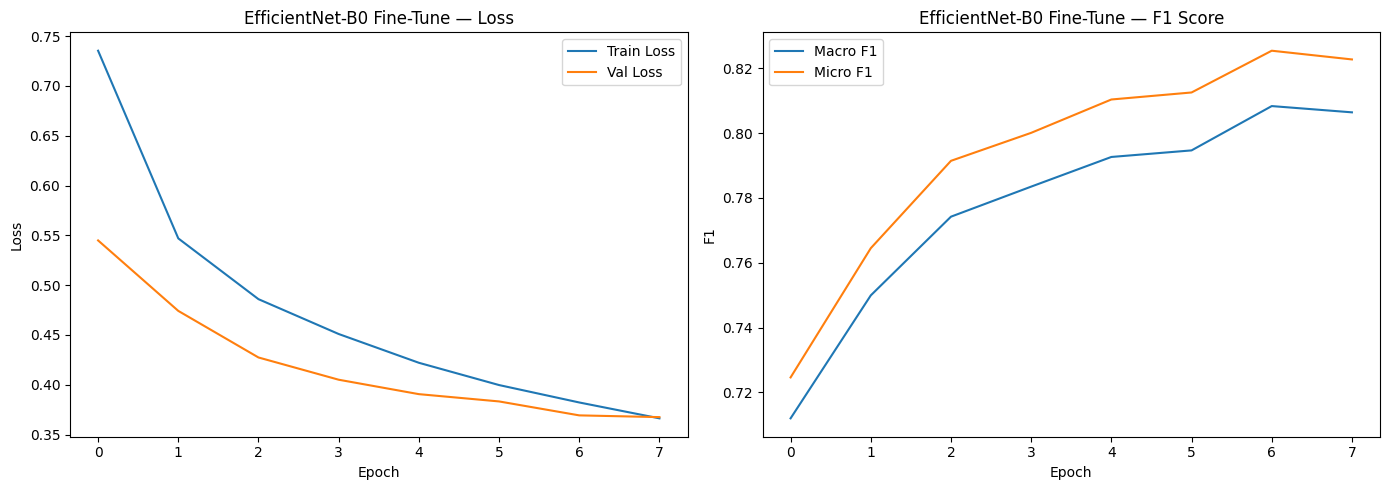

In [12]:
# ===============================
#  Fine-Tune: Training Curves
# ===============================

plot_history(history_finetune, f'EfficientNet-{MODEL_VARIANT.upper()} Fine-Tune')


===== EfficientNet-B0 Fine-Tune — Validation Evaluation =====


Evaluating EfficientNet-B0 Fine-Tune: 100%|██████████| 742/742 [01:17<00:00,  9.58it/s]



===== Per-Class Metrics — EfficientNet-B0 Fine-Tune =====
  Class 0:
    Precision: 0.8714  Recall: 0.8642  F1: 0.8678  AUC: 0.9404
  Class 1:
    Precision: 0.8511  Recall: 0.9393  F1: 0.8931  AUC: 0.9751
  Class 2:
    Precision: 0.6091  Recall: 0.8853  F1: 0.7217  AUC: 0.9582
  Class 3:
    Precision: 0.6253  Recall: 0.9189  F1: 0.7442  AUC: 0.9412
  Class 4:
    Precision: 0.7246  Recall: 0.9314  F1: 0.8151  AUC: 0.9608

===== Overall Metrics — EfficientNet-B0 Fine-Tune =====
  Macro F1  : 0.8084
  Micro F1  : 0.8255
  Macro AUC : 0.9551


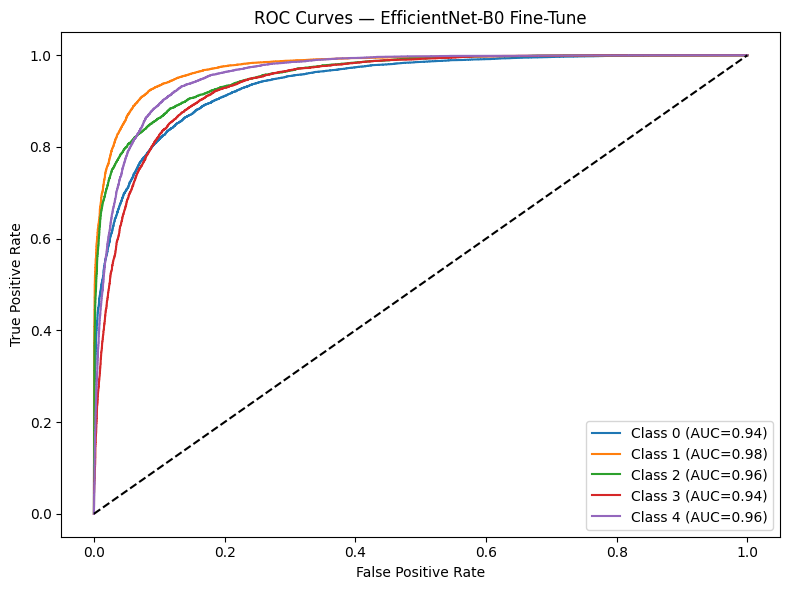

Final — Macro F1: 0.8084  |  Micro F1: 0.8255


In [13]:
# ===============================
#  Fine-Tune: Evaluation
# ===============================

print(f'\n===== EfficientNet-{MODEL_VARIANT.upper()} Fine-Tune — Validation Evaluation =====')
macro_f1_ft, micro_f1_ft = evaluate_model(
    model_finetune, val_loader,
    title=f'EfficientNet-{MODEL_VARIANT.upper()} Fine-Tune'
)
print(f'Final — Macro F1: {macro_f1_ft:.4f}  |  Micro F1: {micro_f1_ft:.4f}')

---
# ▶ TRAINING 2 of 3 — From Scratch

- **No pretrained weights** (random initialisation)
- All layers trainable
- LR = 1e-4, weight-decay = 1e-4
- No mixed precision (optional — set `use_amp=True` if desired)

In [14]:
# ===============================
#  Training from Scratch
# ===============================

SCRATCH_SAVE = f'/kaggle/working/efficientnet_{MODEL_VARIANT}_best_scratch.pth'

print(f'--- Building EfficientNet-{MODEL_VARIANT.upper()} (scratch) ---')
model_scratch = build_efficientnet(MODEL_VARIANT, 'scratch')

print(f'--- Training (scratch) for {EPOCHS} epochs ---')
model_scratch, history_scratch = train_model(
    model_scratch,
    strategy_label='scratch',
    save_path=SCRATCH_SAVE,
    use_amp=False   # scratch is slower; enable AMP if you need speed
)

--- Building EfficientNet-B0 (scratch) ---
  EfficientNet-B0 [scratch] — trainable params: 4,013,953 / 4,013,953
--- Training (scratch) for 8 epochs ---


[scratch] Epoch 1/8: 100%|██████████| 4506/4506 [12:44<00:00,  5.90it/s]



Epoch [1/8]
  Train Loss : 0.9679
  Val   Loss : 0.9090
  Macro F1   : 0.4974   Micro F1: 0.4932
  ✅ Best model saved → /kaggle/working/efficientnet_b0_best_scratch.pth  (Macro F1 = 0.4974)


[scratch] Epoch 2/8: 100%|██████████| 4506/4506 [12:41<00:00,  5.92it/s]



Epoch [2/8]
  Train Loss : 0.8511
  Val   Loss : 0.7648
  Macro F1   : 0.5784   Micro F1: 0.5852
  ✅ Best model saved → /kaggle/working/efficientnet_b0_best_scratch.pth  (Macro F1 = 0.5784)


...


Epoch [6/8]
  Train Loss : 0.6125
  Val   Loss : 0.5730
  Macro F1   : 0.6950   Micro F1: 0.7106
  ✅ Best model saved → /kaggle/working/efficientnet_b0_best_scratch.pth  (Macro F1 = 0.6950)


[scratch] Epoch 7/8: 100%|██████████| 4506/4506 [12:20<00:00,  6.08it/s]



Epoch [7/8]
  Train Loss : 0.5886
  Val   Loss : 0.5495
  Macro F1   : 0.7085   Micro F1: 0.7261
  ✅ Best model saved → /kaggle/working/efficientnet_b0_best_scratch.pth  (Macro F1 = 0.7085)


[scratch] Epoch 8/8: 100%|██████████| 4506/4506 [12:24<00:00,  6.05it/s]



Epoch [8/8]
  Train Loss : 0.5683
  Val   Loss : 0.5594
  Macro F1   : 0.7018   Micro F1: 0.7188

Training complete [scratch]. Best Macro F1: 0.7085


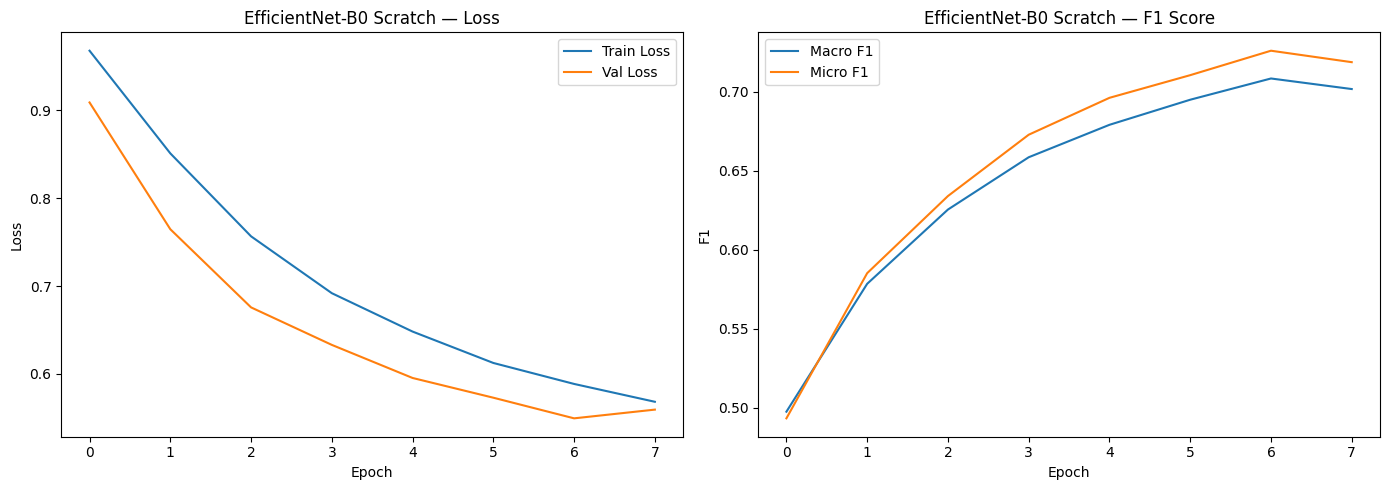

In [15]:
# ===============================
#  Scratch: Training Curves
# ===============================

plot_history(history_scratch, f'EfficientNet-{MODEL_VARIANT.upper()} Scratch')


===== EfficientNet-B0 Scratch — Validation Evaluation =====


Evaluating EfficientNet-B0 Scratch: 100%|██████████| 742/742 [01:17<00:00,  9.63it/s]



===== Per-Class Metrics — EfficientNet-B0 Scratch =====
  Class 0:
    Precision: 0.8170  Recall: 0.7776  F1: 0.7968  AUC: 0.8831
  Class 1:
    Precision: 0.8240  Recall: 0.8675  F1: 0.8452  AUC: 0.9469
  Class 2:
    Precision: 0.4723  Recall: 0.8389  F1: 0.6043  AUC: 0.9112
  Class 3:
    Precision: 0.4811  Recall: 0.8785  F1: 0.6217  AUC: 0.8652
  Class 4:
    Precision: 0.5425  Recall: 0.8912  F1: 0.6744  AUC: 0.8949

===== Overall Metrics — EfficientNet-B0 Scratch =====
  Macro F1  : 0.7085
  Micro F1  : 0.7261
  Macro AUC : 0.9003


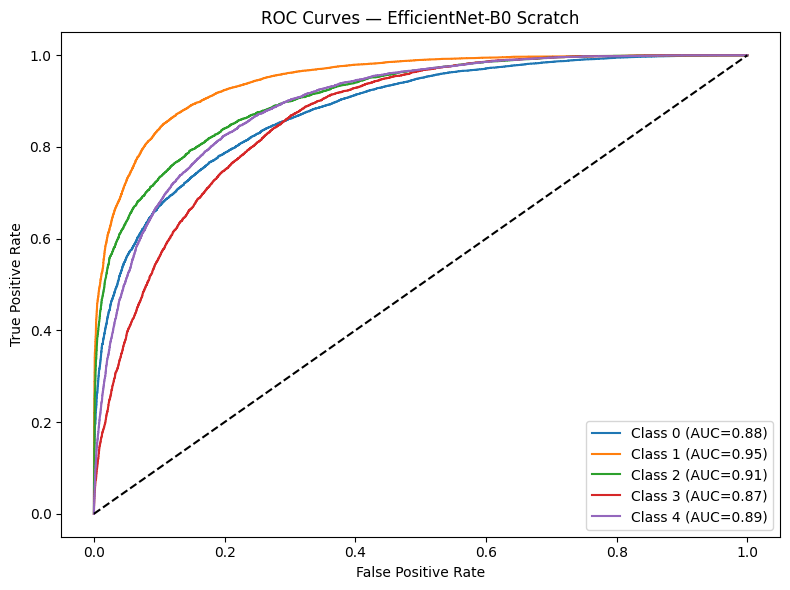

Final — Macro F1: 0.7085  |  Micro F1: 0.7261


In [16]:
# ===============================
#  Scratch: Evaluation
# ===============================

print(f'\n===== EfficientNet-{MODEL_VARIANT.upper()} Scratch — Validation Evaluation =====')
macro_f1_sc, micro_f1_sc = evaluate_model(
    model_scratch, val_loader,
    title=f'EfficientNet-{MODEL_VARIANT.upper()} Scratch'
)
print(f'Final — Macro F1: {macro_f1_sc:.4f}  |  Micro F1: {micro_f1_sc:.4f}')

---
# ▶ TRAINING 3 of 3 — Transfer Learning (frozen backbone)

- Pretrained ImageNet weights
- **Backbone frozen** — only the classifier head trains
- LR = 1e-4
- Mixed precision enabled

In [17]:
# ===============================
#  Transfer Learning
# ===============================

TRANSFER_SAVE = f'/kaggle/working/efficientnet_{MODEL_VARIANT}_best_transfer.pth'

print(f'--- Building EfficientNet-{MODEL_VARIANT.upper()} (transfer) ---')
model_transfer = build_efficientnet(MODEL_VARIANT, 'transfer')

print(f'--- Training (transfer) for {EPOCHS} epochs ---')
model_transfer, history_transfer = train_model(
    model_transfer,
    strategy_label='transfer',
    save_path=TRANSFER_SAVE,
    use_amp=True
)

--- Building EfficientNet-B0 (transfer) ---
  EfficientNet-B0 [transfer] — trainable params: 6,405 / 4,013,953
--- Training (transfer) for 8 epochs ---


[transfer] Epoch 1/8: 100%|██████████| 4506/4506 [10:49<00:00,  6.94it/s]



Epoch [1/8]
  Train Loss : 0.9774
  Val   Loss : 0.9076
  Macro F1   : 0.4812   Micro F1: 0.4710
  ✅ Best model saved → /kaggle/working/efficientnet_b0_best_transfer.pth  (Macro F1 = 0.4812)


[transfer] Epoch 2/8: 100%|██████████| 4506/4506 [10:57<00:00,  6.86it/s]



Epoch [2/8]
  Train Loss : 0.9271
  Val   Loss : 0.8672
  Macro F1   : 0.5260   Micro F1: 0.5231
  ✅ Best model saved → /kaggle/working/efficientnet_b0_best_transfer.pth  (Macro F1 = 0.5260)


...


Epoch [6/8]
  Train Loss : 0.8590
  Val   Loss : 0.8084
  Macro F1   : 0.5596   Micro F1: 0.5636


[transfer] Epoch 7/8: 100%|██████████| 4506/4506 [10:41<00:00,  7.02it/s]



Epoch [7/8]
  Train Loss : 0.8519
  Val   Loss : 0.7986
  Macro F1   : 0.5669   Micro F1: 0.5743
  ✅ Best model saved → /kaggle/working/efficientnet_b0_best_transfer.pth  (Macro F1 = 0.5669)


[transfer] Epoch 8/8: 100%|██████████| 4506/4506 [10:39<00:00,  7.05it/s]



Epoch [8/8]
  Train Loss : 0.8465
  Val   Loss : 0.7948
  Macro F1   : 0.5687   Micro F1: 0.5759
  ✅ Best model saved → /kaggle/working/efficientnet_b0_best_transfer.pth  (Macro F1 = 0.5687)

Training complete [transfer]. Best Macro F1: 0.5687


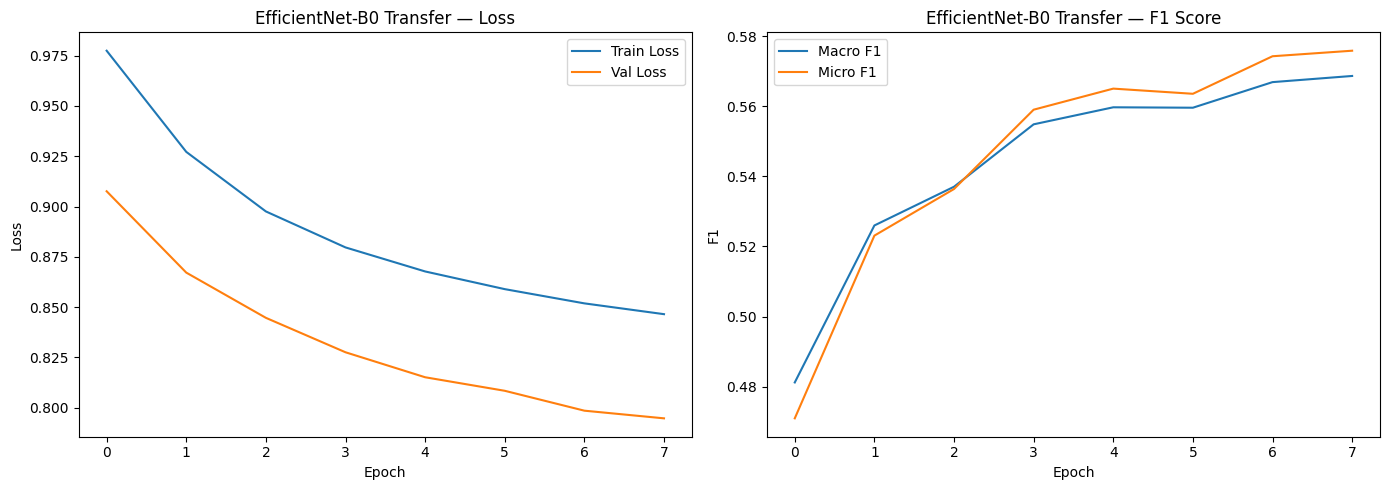

In [18]:
# ===============================
#  Transfer: Training Curves
# ===============================

plot_history(history_transfer, f'EfficientNet-{MODEL_VARIANT.upper()} Transfer')


===== EfficientNet-B0 Transfer — Validation Evaluation =====


Evaluating EfficientNet-B0 Transfer: 100%|██████████| 742/742 [01:17<00:00,  9.62it/s]



===== Per-Class Metrics — EfficientNet-B0 Transfer =====
  Class 0:
    Precision: 0.7143  Recall: 0.6219  F1: 0.6649  AUC: 0.7422
  Class 1:
    Precision: 0.6882  Recall: 0.7062  F1: 0.6971  AUC: 0.8256
  Class 2:
    Precision: 0.2897  Recall: 0.8018  F1: 0.4256  AUC: 0.7642
  Class 3:
    Precision: 0.3358  Recall: 0.8803  F1: 0.4862  AUC: 0.7449
  Class 4:
    Precision: 0.4150  Recall: 0.9071  F1: 0.5694  AUC: 0.8148

===== Overall Metrics — EfficientNet-B0 Transfer =====
  Macro F1  : 0.5687
  Micro F1  : 0.5759
  Macro AUC : 0.7783


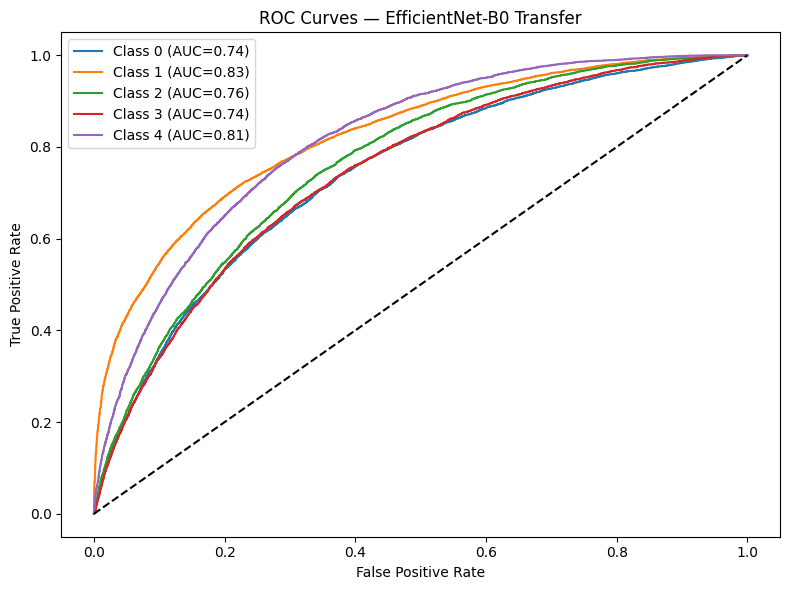

Final — Macro F1: 0.5687  |  Micro F1: 0.5759


In [19]:
# ===============================
#  Transfer: Evaluation
# ===============================

print(f'\n===== EfficientNet-{MODEL_VARIANT.upper()} Transfer — Validation Evaluation =====')
macro_f1_tr, micro_f1_tr = evaluate_model(
    model_transfer, val_loader,
    title=f'EfficientNet-{MODEL_VARIANT.upper()} Transfer'
)
print(f'Final — Macro F1: {macro_f1_tr:.4f}  |  Micro F1: {micro_f1_tr:.4f}')

---
## Final Model Comparison

In [20]:
# ===============================
#  Final Comparison Table
# ===============================

variant_upper = MODEL_VARIANT.upper()

print('\n' + '='*55)
print(f'   Final Comparison — EfficientNet-{variant_upper}')
print('='*55)
print(f'{"Model":<30}{"Macro F1":<12}{"Micro F1"}')
print('-'*55)
print(f'{f"EfficientNet-{variant_upper} Fine-Tune":<30}{macro_f1_ft:.4f}      {micro_f1_ft:.4f}')
print(f'{f"EfficientNet-{variant_upper} Scratch":<30}{macro_f1_sc:.4f}      {micro_f1_sc:.4f}')
print(f'{f"EfficientNet-{variant_upper} Transfer":<30}{macro_f1_tr:.4f}      {micro_f1_tr:.4f}')
print('='*55)

best_strategy = max(
    [('Fine-Tune', macro_f1_ft), ('Scratch', macro_f1_sc), ('Transfer', macro_f1_tr)],
    key=lambda x: x[1]
)
print(f'\n🏆 Best strategy: {best_strategy[0]} (Macro F1 = {best_strategy[1]:.4f})')


   Final Comparison — EfficientNet-B0
Model                         Macro F1    Micro F1
-------------------------------------------------------
EfficientNet-B0 Fine-Tune     0.8084      0.8255
EfficientNet-B0 Scratch       0.7085      0.7261
EfficientNet-B0 Transfer      0.5687      0.5759

🏆 Best strategy: Fine-Tune (Macro F1 = 0.8084)


In [21]:
# ===============================
#  Verify Saved Checkpoints
# ===============================

print('Saved model files in /kaggle/working/:')
for fname in sorted(os.listdir('/kaggle/working/')):
    if fname.startswith('efficientnet'):
        fpath = os.path.join('/kaggle/working/', fname)
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f'  {fname}  ({size_mb:.1f} MB)')

Saved model files in /kaggle/working/:
  efficientnet_b0_best_finetune.pth  (15.6 MB)
  efficientnet_b0_best_scratch.pth  (15.6 MB)
  efficientnet_b0_best_transfer.pth  (15.6 MB)


---
## How to Reload a Saved Model After Session Restart

If your Kaggle session restarts, reload the best checkpoint like this:

```python
import torch
import torchvision.models as models
import torch.nn as nn

MODEL_VARIANT = 'b0'   # or 'b2'
NUM_CLASSES   = 5
device        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Rebuild architecture ---
if MODEL_VARIANT == 'b0':
    model = models.efficientnet_b0(weights=None)
else:
    model = models.efficientnet_b2(weights=None)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
model = model.to(device)

# --- Load weights ---
CHECKPOINT = f'/kaggle/working/efficientnet_{MODEL_VARIANT}_best_finetune.pth'
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.eval()
print('Model loaded from', CHECKPOINT)
```